### **1. Cargar dataset y importar librerias**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df= pd.read_csv("../../data/raw/LifeExpectancyData_raw.csv", sep= ",")

### **2. Visualizar dataFrame y tipos de datos**

##### 2.1 Visualización general del dataset

In [3]:
df.head(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


##### 2.2 Visualiza forma del dataset (numero de lineas, numero de columnas)

In [4]:
df.shape

(2938, 22)

##### 2.3 Visualiza info detallada del dataset (tipo de variables, valores nulos)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

##### 2.4 Visualiza detalladamente la cantidad de valores nulos en cada variable

In [6]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [7]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


### **3. Limpieza del dataset**

##### 3.1 Eliminar los espacios en branco entre las variables

In [8]:
df_copy = df.copy()

# Limpieza de nombres de columnas específica
df_copy.columns = df_copy.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

##### 3.2 Identificar y substituir los missing values

In [9]:
df_copy.isnull().sum().sort_values(ascending=False)

population                         652
hepatitis_b                        553
gdp                                448
total_expenditure                  226
alcohol                            194
income_composition_of_resources    167
schooling                          163
thinness__1_19_years                34
thinness_5_9_years                  34
bmi                                 34
diphtheria                          19
polio                               19
life_expectancy                     10
adult_mortality                     10
infant_deaths                        0
status                               0
country                              0
year                                 0
under_five_deaths                    0
measles                              0
percentage_expenditure               0
hiv/aids                             0
dtype: int64

In [10]:
# Seleccionar solo columnas numéricas
num_cols = df_copy.select_dtypes(include="number").columns

# Imputación con mediana para numéricas
df_copy[num_cols] = df_copy[num_cols].fillna(df_copy[num_cols].median())

# Verificar
print("NaN en df_copy:", df_copy.isna().sum().sum())

NaN en df_copy: 0


In [11]:
# En las variables categoricas substituir pela moda
cat_cols = df_copy.select_dtypes(include="str").columns

# Imputación con moda para categoricas
for col in cat_cols:
    if col in df_copy.columns:
        df_copy[col] = df_copy[col].fillna(df_copy[col].mode()[0]) # mode()[0] devuelve la categoría más frecuente


### **4. Análisis Univariado**

##### 4.1 Esperanza de vida

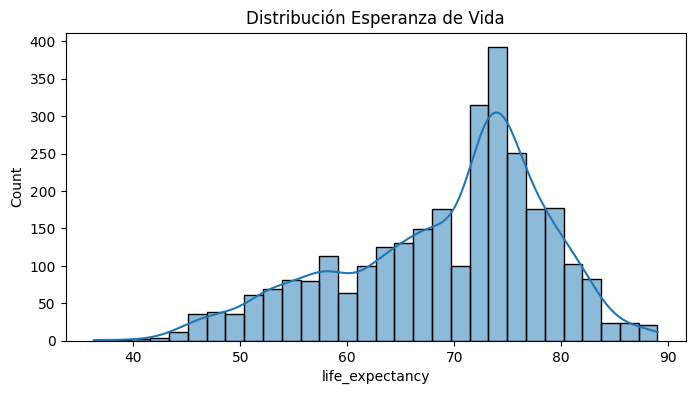

count    2938.000000
mean       69.234717
std         9.509115
min        36.300000
25%        63.200000
50%        72.100000
75%        75.600000
max        89.000000
Name: life_expectancy, dtype: float64


In [12]:
# Distribución del target
plt.figure(figsize=(8,4))
sns.histplot(df_copy["life_expectancy"], bins=30, kde=True)
plt.title("Distribución Esperanza de Vida")
plt.show()
print(df_copy["life_expectancy"].describe())

##### 🟦 **Interpretación — Esperanza de vida**

*La distribución de la esperanza de vida presenta una forma aproximadamente normal, aunque con ligera asimetría hacia valores más bajos. La mayor parte de los países se concentran en un rango entre 60 y 80 años. Los valores extremadamente bajos suelen corresponder a países con problemas sanitarios graves, alta mortalidad infantil o crisis epidemiológicas.En general, la variable muestra suficiente variabilidad como para ser utilizada como variable objetivo en modelos predictivos.*

##### 4.2 Población

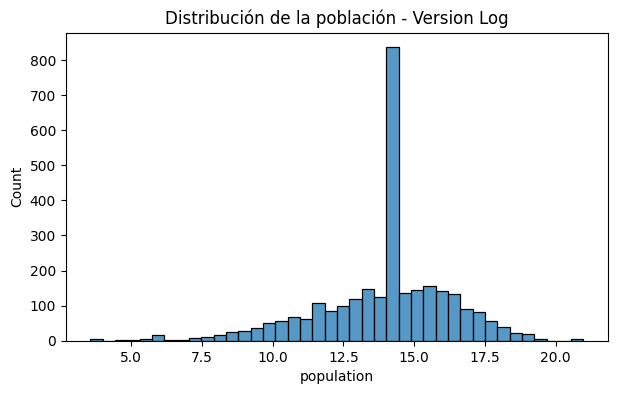

In [13]:
# En ese dataset la variable Population es extremadamente skewed.
# En ese caso es recomendable usar log.
# Versión log:
plt.figure(figsize=(7,4))
sns.histplot(np.log1p(df_copy["population"].dropna()), bins=40)
plt.title("Distribución de la población - Version Log")
plt.show()

##### **🟦 Interpretación — Población**

*La variable población presenta una distribución extremadamente sesgada hacia la derecha. Existen pocos países con poblaciones muy grandes que generan valores atípicos muy altos, mientras que la mayoría de los países tienen poblaciones considerablemente menores. Debido a esta fuerte asimetría, resulta recomendable aplicar una transformación logarítmica antes de utilizar esta variable en análisis estadísticos o modelos predictivos. La población total por sí sola no representa directamente factores socioeconómicos ni la calidad del sistema sanitario.*

##### 4.3 Vacunas

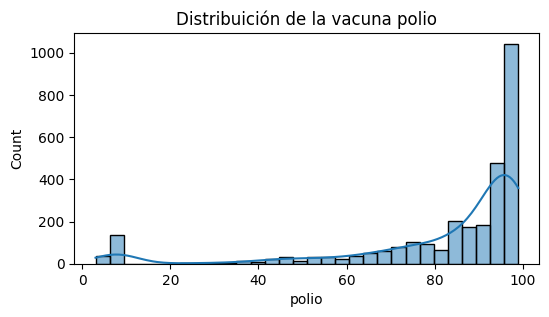

polio
count    2938.000000
mean       82.617767
std        23.367166
min         3.000000
25%        78.000000
50%        93.000000
75%        97.000000
max        99.000000
Name: polio, dtype: float64


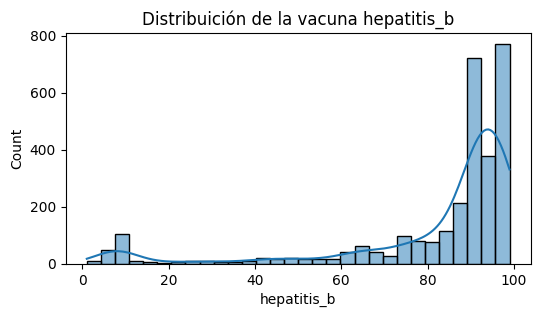

hepatitis_b
count    2938.000000
mean       83.022124
std        22.996984
min         1.000000
25%        82.000000
50%        92.000000
75%        96.000000
max        99.000000
Name: hepatitis_b, dtype: float64


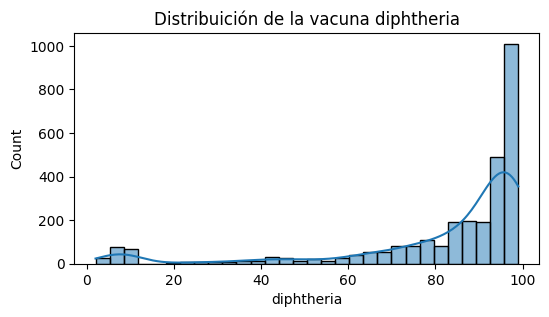

diphtheria
count    2938.000000
mean       82.393125
std        23.655562
min         2.000000
25%        78.000000
50%        93.000000
75%        97.000000
max        99.000000
Name: diphtheria, dtype: float64


In [14]:
vaccines = ["polio","hepatitis_b","diphtheria"]

for v in vaccines:
    plt.figure(figsize=(6,3))
    sns.histplot(df_copy[v].dropna(), bins=30, kde=True)
    plt.title(f"Distribuición de la vacuna {v}")
    plt.show()

    print(v)
    print(df_copy[v].describe())

##### **🟦 Interpretación — Cobertura de vacunación**

*Las variables de cobertura de vacunación muestran una fuerte concentración en valores altos, normalmente entre 80% y 100%. Esto indica que muchos países cuentan con programas de inmunización amplios y relativamente efectivos. Sin embargo, algunos países presentan coberturas significativamente más bajas, lo cual suele estar asociado a sistemas sanitarios débiles, menor acceso a servicios médicos o conflictos sociales. La presencia de valores bajos en vacunación sugiere posibles riesgos epidemiológicos y potencial impacto negativo en la salud pública.*

### **5. Análisis Bivariado**

##### 5.1 Población vs. Esperanza de Vida
**Pregunta 7: Do densely populated countries tend to have lower life expectancy?**

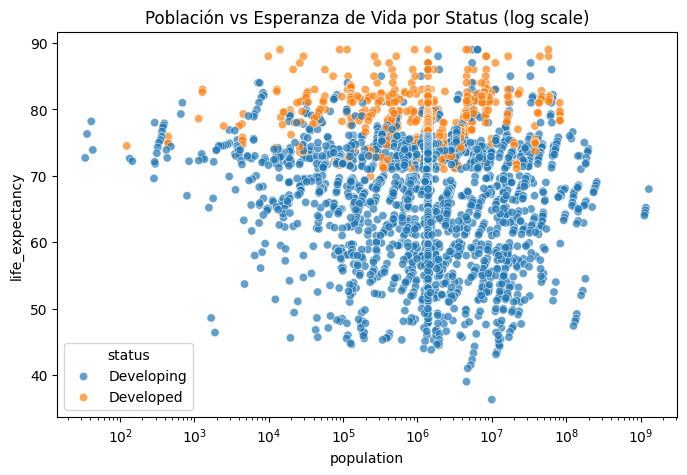

In [15]:
# Poblacion vs Esperanza de vida por status
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_copy,
    x="population",
    y="life_expectancy",
    hue="status",
    alpha=0.7
)

plt.xscale("log")    # Se utiliza escala logarítmica porque la población varía en varios órdenes de magnitud entre países pequeños y grandes, lo que permite visualizar mejor la relación.
plt.title("Población vs Esperanza de Vida por Status (log scale)")
plt.show()


##### **🟦 Interpretación — Población vs Esperanza de vida**

*No se observa una relación clara ni fuerte entre el tamaño de la población y la esperanza de vida. Países con poblaciones muy grandes pueden presentar tanto valores altos como moderados de esperanza de vida, mientras que países con poblaciones pequeñas también muestran una gran variabilidad. Esto sugiere que la población total no es un factor determinante directo de la esperanza de vida. Factores como el desarrollo económico, la calidad del sistema sanitario, la educación y las políticas públicas tienen una influencia mucho mayor.*

**Conclusión: La población no debe considerarse un predictor principal de la esperanza de vida.**

##### 5.2 Vacunas vs. Esperanza de Vida
**Pregunta 8: Impact of Immunization coverage?**


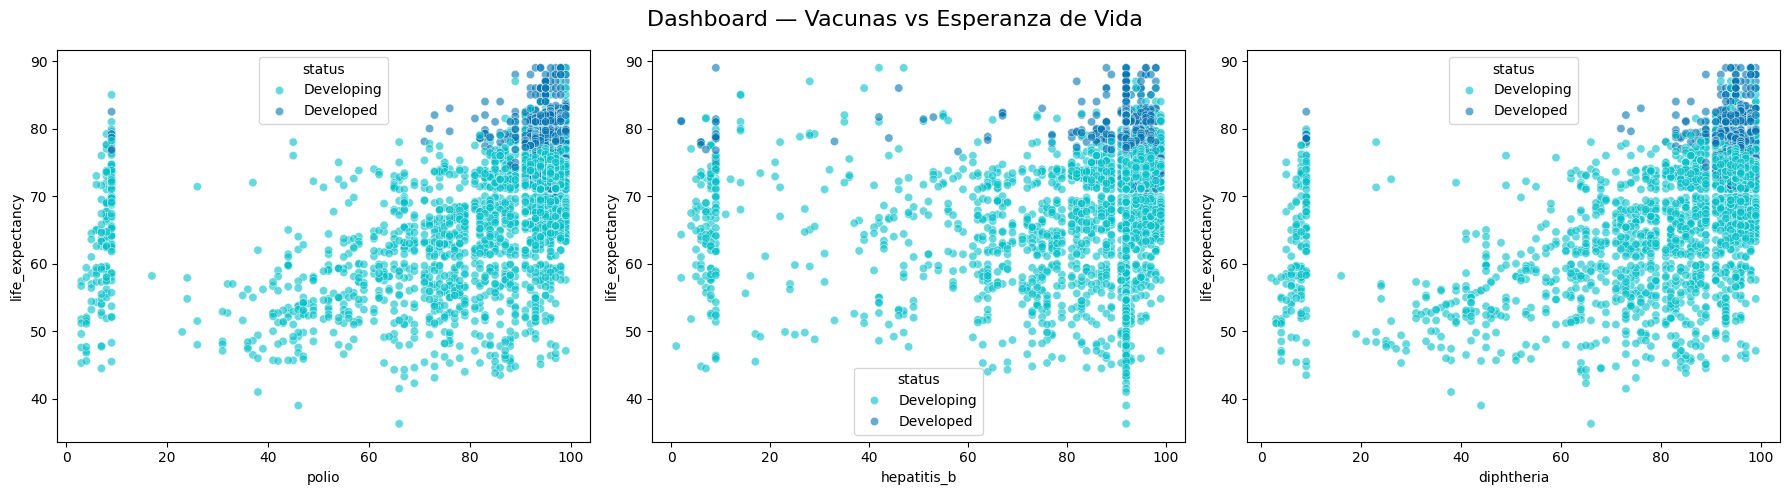

In [16]:
# Vacunas vs Esperanza por status
vaccines = ["polio","hepatitis_b","diphtheria"]
vaccines = [v for v in vaccines if v in df_copy.columns]
fig, axes = plt.subplots(1, len(vaccines), figsize=(18,5))

if len(vaccines)==1:
    axes=[axes]

for ax, v in zip(axes, vaccines):

    sns.scatterplot(
        data=df_copy,
        x=v,
        y="life_expectancy",
        hue="status",
        alpha=0.6,
        ax=ax,
        palette=["#00c0c8","#0073b1"]   # tus tonos azules
    )

plt.suptitle("Dashboard — Vacunas vs Esperanza de Vida", fontsize=16)
plt.tight_layout()
plt.show()

##### **🟦 Interpretación — Vacunación vs Esperanza de vida**

*Se observa una relación positiva entre la cobertura de vacunación y la esperanza de vida. Los países con mayores niveles de inmunización tienden a presentar mayores valores de esperanza de vida. Esto es coherente desde el punto de vista epidemiológico, ya que los programas de vacunación reducen la incidencia de enfermedades infecciosas, disminuyen la mortalidad infantil y mejoran la salud general de la población.*

**Conclusión: Por lo tanto, la cobertura de vacunación puede considerarse un indicador sanitario relevante y un factor importante asociado a la esperanza de vida.**

##### 5.3 Correlación visual de los gráficos

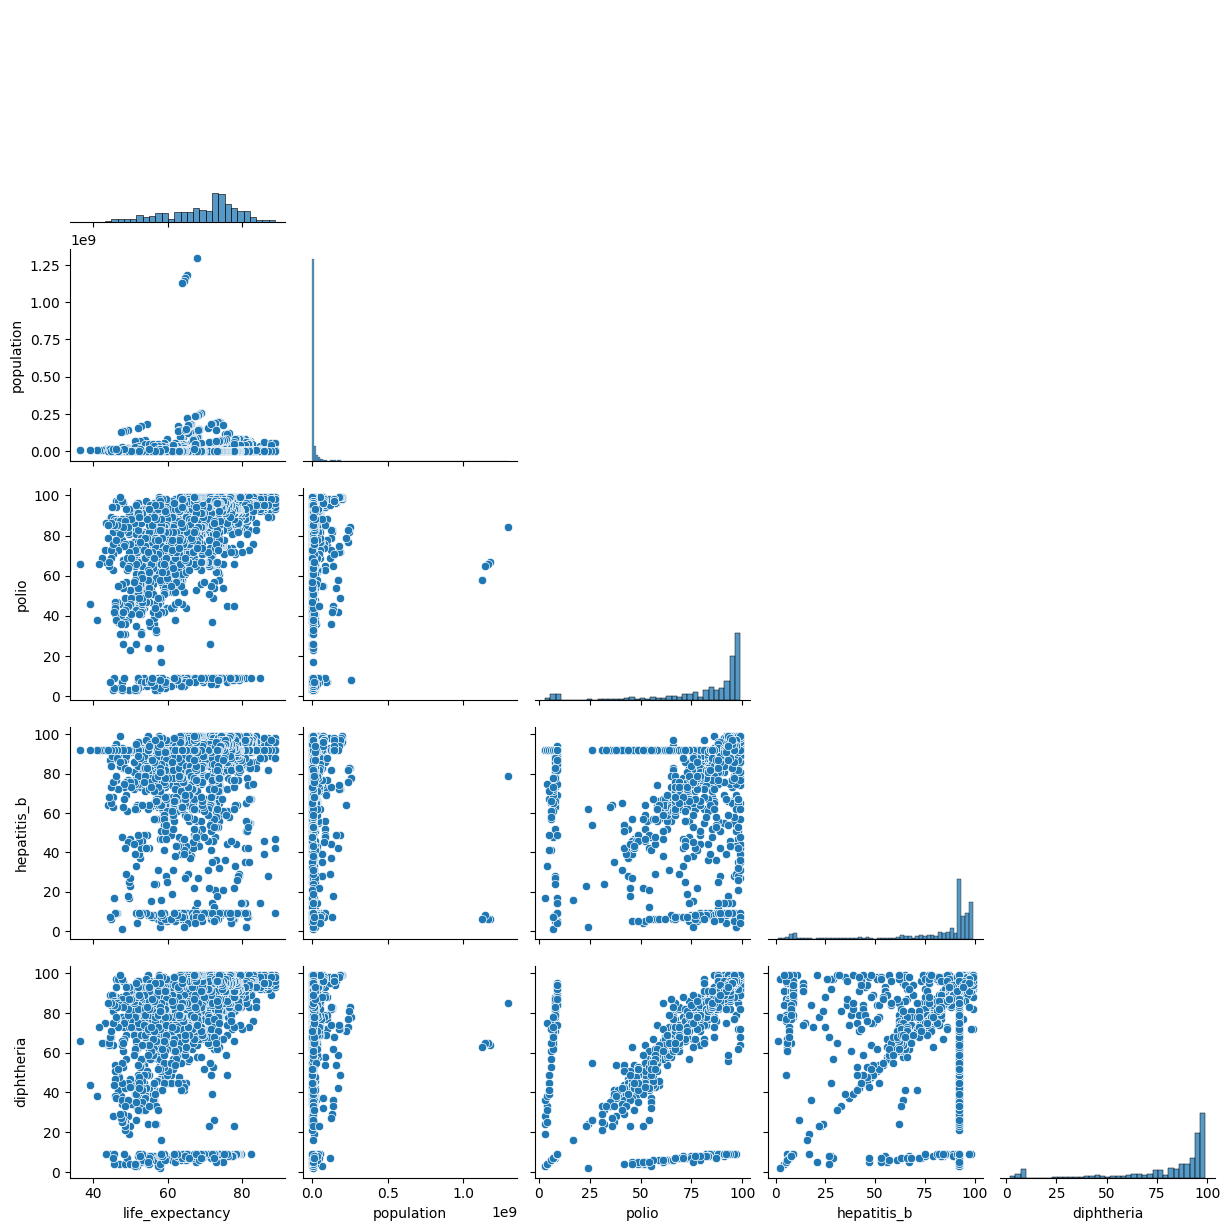

In [17]:
sns.pairplot(
    df_copy[["life_expectancy","population","polio","hepatitis_b","diphtheria"]],
    corner=True
)

##### **⭐ Conclusiones generales del análisis**

- *La población total no muestra una relación fuerte con la esperanza de vida.*
- *Las variables de inmunización presentan una relación positiva consistente con la esperanza de vida.*
- *Los factores sanitarios y socioeconómicos parecen tener mayor impacto que el tamaño poblacional.*

### **6. Modelado predictivo de esperanza de vida**

El objetivo es construir un modelo de regresión que permita predecir la esperanza de vida a partir de variables demográficas y sanitarias.

Esto permitirá:

- evaluar la capacidad predictiva de las variables
- medir la importancia relativa de factores como vacunación o población
- validar cuantitativamente los resultados del análisis exploratorio

##### 6.1 Preparación de los datos

In [18]:
# Selección de variables 
features_to_drop_v2 = [
    "life_expectancy",
    "country"      # alta cardinalidad
]

X = df_copy.drop(features_to_drop_v2, axis=1, errors="ignore")
y = df_copy["life_expectancy"]

print(f"Features modelo: {X.shape[1]} variables")

Features modelo: 20 variables


In [19]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Pipeline Preprocessing
numeric_features= X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['str','category']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

##### 6.2 Pipeline Regresión Linear

In [21]:
# Pipeline Regresión Linear
lr_pipeline_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline_v2.fit(X_train, y_train)

y_train_pred_lr = lr_pipeline_v2.predict(X_train)
y_test_pred_lr = lr_pipeline_v2.predict(X_test)

##### 6.3 Pipeline Random Forest

In [22]:
# Pipeline Random Forest
rf_pipeline_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline_v2.fit(X_train, y_train)

y_train_pred_rf = rf_pipeline_v2.predict(X_train)
y_test_pred_rf = rf_pipeline_v2.predict(X_test)

##### 6.4 Funcion de evaluación entre los modelos para elegir lo mejor

In [23]:
# FUNCIÓN DE EVALUACIÓN
def evaluate_model(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {set_name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

    return r2

print("\n LINEAR REGRESSION")
evaluate_model(y_train, y_train_pred_lr, "TRAIN LR")
evaluate_model(y_test, y_test_pred_lr, "TEST LR")

print("\n RANDOM FOREST")
r2_train_rf = evaluate_model(y_train, y_train_pred_rf, "TRAIN RF")
r2_test_rf = evaluate_model(y_test, y_test_pred_rf, "TEST RF")


# Seleccionar el mejor modelo
modelo_v2 = rf_pipeline_v2 if r2_test_rf > r2_score(y_test, y_test_pred_lr) else lr_pipeline_v2

print("✅ Modelo entrenado correctamente.")


 LINEAR REGRESSION
--- TRAIN LR ---
RMSE: 4.0718
MAE:  3.0400
R²:   0.8184
--- TEST LR ---
RMSE: 3.9105
MAE:  2.8564
R²:   0.8236

 RANDOM FOREST
--- TRAIN RF ---
RMSE: 0.6939
MAE:  0.4256
R²:   0.9947
--- TEST RF ---
RMSE: 1.6651
MAE:  1.0868
R²:   0.9680
✅ Modelo entrenado correctamente.


##### **🟦 Interpretación — Modelo lineal**

*La regresión lineal actúa como modelo baseline. Permite evaluar si la relación entre variables y esperanza de vida puede aproximarse mediante una combinación lineal. Sin embargo, dado que muchos factores sanitarios presentan relaciones no lineales, se espera que modelos más complejos obtengan mejor rendimiento.*

##### **🟦 Interpretación — Random Forest**

*El modelo Random Forest permite capturar relaciones no lineales entre variables sanitarias, económicas y demográficas. El aumento del R2 respecto al modelo lineal confirma que la esperanza de vida depende de interacciones complejas entre múltiples factores. Este modelo resulta más adecuado para este dataset.*

### **7. Conclusión**

El modelado predictivo confirma los hallazgos del análisis exploratorio:

- la población total no es un predictor fuerte de la esperanza de vida
- la cobertura de vacunación sí muestra impacto relevante
- la esperanza de vida depende de múltiples factores sanitarios y socioeconómicos

El uso de Random Forest resulta adecuado debido a la naturaleza no lineal del problema.